In [1]:
# !pip install requests pandas yfinance numpy cloudscraper xlrd lxml html5lib playwright openpyxl html5lib matplotlib

import os
import sys
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from dateutil.relativedelta import relativedelta
from datetime import datetime
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)

sys.version_info
# !python --version
# print("當前 Kernel 使用的版本:", sys.version.split()[0])
# print("當前 Kernel 引用的執行檔路徑:", sys.executable)
# !jupyter kernelspec list
# !pip install finlab


sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)

In [ ]:
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
# ==========================================
# 1. 查詢機制：爬取加權指數與紅藍燈訊號
# ==========================================

def fetch_data_robust(start_year=2003, file_path='ndc.xls'):
    now = datetime.now()
    url = f"https://index.ndc.gov.tw/n/excel/data/eco/indicators?sy={start_year}&sm=1&ey={now.year}&em={now.month}&id=2%2C12&sq=0,0,0&file_type=xls"
    
    ndc_df = None

    # 第一階段：檢查並偵錯讀取本地檔案
    if os.path.exists(file_path):
        print(f"🔍 進入 Debug 模式：讀取本地檔案 '{file_path}'...")
        try:
            # 1. 使用您指定的 debug_read 方式：xlrd 引擎且不設表頭
            raw_data = pd.read_excel(file_path, engine='xlrd', header=None)
            
            print("📊 [Debug] 原始資料前 15 列預覽：")
            print(raw_data.head(15))
            
            # 2. 根據截圖邏輯提取：跳過前 2 列，取第 0 欄與第 2 欄
            ndc_df = raw_data.iloc[2:, [0, 2]].copy()
            ndc_df.columns = ['Date', 'Score']
            print("✅ 本地 Excel 解析成功！")
            
        except Exception as e:
            print(f"⚠️ xlrd 讀取失敗（報錯：{e}），嘗試切換至 HTML 解析模式...")
            # 備援：多重編碼解析 (處理假 XLS)
            for enc in ['cp950', 'utf-8', 'utf-16']:
                try:
                    tables = pd.read_html(file_path, encoding=enc)
                    raw_html_df = tables[0]
                    ndc_df = raw_html_df.iloc[2:, [0, 2]].copy()
                    ndc_df.columns = ['Date', 'Score']
                    print(f"✅ 使用 HTML 編碼 '{enc}' 解析成功！")
                    break
                except:
                    continue

    # 第二階段：若無檔案或解析失敗，嘗試自動抓取
    if ndc_df is None:
        print(f"🌐 嘗試自動從國發會網頁抓取數據...")
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            
            # 先存檔，方便下次 debug
            with open(file_path, 'wb') as f:
                f.write(res.content)
            print(f"✅ 下載存檔成功：{file_path}，請重新執行程式以進入 Debug 解析。")
            return None
                
        except Exception as e:
            # 第三階段：抓取失敗，顯示手動下載提示
            print(f"❌ 自動抓取失敗: {e}")
            print("\n" + "="*50)
            print("🚨 【請手動下載資料】 🚨")
            print('請用瀏覽器下載下方網址，命名為 {file_path} 放入目錄：')
            print(f"\n{url}\n")
            print("="*50 + "\n")
            return None

    # --- 後續資料清洗與 0050 合併 ---
    # 清洗掉非日期或非分數的雜質
    ndc_df = ndc_df.dropna(subset=['Date', 'Score'])
    ndc_df['Date'] = pd.to_datetime(ndc_df['Date'], errors='coerce')
    ndc_df = ndc_df.dropna(subset=['Date'])
    ndc_df.set_index('Date', inplace=True)
    ndc_df['Score'] = pd.to_numeric(ndc_df['Score'], errors='coerce')

    # 燈號判定
    conditions = [(ndc_df['Score'] >= 38), (ndc_df['Score'] <= 16)]
    ndc_df['Light'] = np.select(conditions, ['紅', '藍'], default='其他')

    # 抓取 0050
    print("正在獲取 0050 歷史報價並合併資料...")
    etf = yf.Ticker("0050.TW").history(start=f"{start_year}-01-01", period="max", interval="1mo")
    etf.index = etf.index.tz_localize(None).to_period('M').to_timestamp()
    
    return etf[['Close']].join(ndc_df[['Score', 'Light']], how='left').dropna(subset=['Score'])

    
    
# ==========================================
# 2. 策略函式：輸入資料並產出買賣訊號
# ==========================================
def generate_signals(df):
    """
    注意事項：股市領先基本面，且國發會 T 月的燈號在 T+1 月底才公布。
    為了避免「未來函數(Look-ahead bias)」，我們將燈號訊號向後平移 1 個月。
    亦即：T+1 月底的收盤價，對應的是 T 月的燈號決策。
    """
    strategy_df = df.copy()
    # 訊號遞延 1 個月生效 (符合現實公布時間)
    strategy_df['Signal_Light'] = strategy_df['Light'].shift(1)
    
    # 動作定義：確知上個月藍燈 -> 買進(1)；確知上個月紅燈 -> 賣出(-1)；其他 -> 觀望(0)
    strategy_df['Action'] = 0
    strategy_df.loc[strategy_df['Signal_Light'] == '藍', 'Action'] = 1
    strategy_df.loc[strategy_df['Signal_Light'] == '紅', 'Action'] = -1
    
    return strategy_df

# ==========================================
# 3. 驗證函式：回測並計算自訂月份的平均獲利
# ==========================================
def backtest_strategy(strategy_df, hold_months=6):
    results = []
    # 篩選出所有觸發「買進」的時間點
    buy_dates = strategy_df[strategy_df['Action'] == 1].index
    
    for buy_date in buy_dates:
        # 計算預計賣出的月份
        sell_date = buy_date + relativedelta(months=hold_months)
        
        # 確保回測資料涵蓋到預計賣出的時間
        if sell_date in strategy_df.index:
            buy_price = strategy_df.loc[buy_date, 'Close']
            sell_price = strategy_df.loc[sell_date, 'Close']
            ret_pct = (sell_price - buy_price) / buy_price * 100
            
            results.append({
                '買進月': buy_date.strftime('%Y/%m'),
                '賣出月': sell_date.strftime('%Y/%m'),
                '獲利%': ret_pct
            })
            
    if not results:
        print("查無符合條件或已走完回測時間的交易紀錄。")
        return 0

    res_df = pd.DataFrame(results)
    avg_return = res_df['獲利%'].mean()
    win_rate = (res_df['獲利%'] > 0).mean() * 100
    
    print(f"=== 藍燈買進策略回測 (固定持有 {hold_months} 個月) ===")
    print(f"總交易筆數 : {len(results)} 筆")
    print(f"平均獲利   : {avg_return:.2f}%")
    print(f"交易勝率   : {win_rate:.1f}%")
    print("==================================================")
    
    return avg_return

# ==========================================
# 3. 驗證函式 (進階統計版：新增平均盈虧與總盈虧)
# ==========================================
def backtest_advanced(strategy_df, hold_months=6):
    buy_results = []
    sell_results = []
    
    for current_date in strategy_df.index:
        action = strategy_df.loc[current_date, 'Action']
        if action == 0:
            continue
            
        future_date = current_date + relativedelta(months=hold_months)
        
        if future_date in strategy_df.index:
            current_price = strategy_df.loc[current_date, 'Close']
            future_price = strategy_df.loc[future_date, 'Close']
            ret_pct = (future_price - current_price) / current_price * 100
            
            if action == 1:
                buy_results.append(ret_pct)
            elif action == -1:
                sell_results.append(ret_pct)
                
    # 統計輸出模組
    def print_stats(results, signal_name):
        if not results:
            return f"{signal_name}訊號: 無足夠歷史資料"
            
        res_arr = np.array(results)
        wins = res_arr[res_arr > 0]
        losses = res_arr[res_arr <= 0]
        
        # 計算各項進階核心指標
        win_rate = (len(wins) / len(res_arr)) * 100
        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = np.mean(losses) if len(losses) > 0 else 0
        avg_pnl = np.mean(res_arr)   # 投資真正關心的期望值
        total_pnl = np.sum(res_arr)  # 持續執行的總績效
        
        return (f"[{signal_name}]\n"
                f"樣本總數 : {len(res_arr):>5} 筆\n"
                f"交易勝率 : {win_rate:>6.1f} %\n"
                f"平均獲利 : {avg_win:>6.2f} %\n"
                f"平均虧損 : {avg_loss:>6.2f} %\n"
                f"平均盈虧 : {avg_pnl:>6.2f} %  <-- 策略期望值\n"
                f"總累積盈虧: {total_pnl:>6.2f} %  <-- 長期執行總合")

    print(f"\n=== 訊號出現後持有 {hold_months} 個月之進階統計 ===")
    print(print_stats(buy_results, "買訊 (上月藍燈)"))
    print("-" * 40)
    print(print_stats(sell_results, "賣訊 (上月紅燈)"))
    print("==================================================")

def run_custom_strategy(df, config, monthly_budget=10000):
    """
    更新邏輯：
    1. allocation: [股票比, 現金比] 用於每月 DCA 預算。
    2. action: 'sell' (賣股換錢), 'buy' (花錢買股), 'hold' (不動作, 跟隨配比投入), 'stop' (保留全現金)。
    3. invest: 池子百分比 (0.0 ~ 1.0)。
    4. budget_mult: (新增) 用於控制該燈號下是否繼續投入每月預算。
    """
    dca_ratio = config['allocation'][0] / 100
    reserve_ratio = config['allocation'][1] / 100
    
    shares = 0      # 股票池 (Stock Pool)
    cash_pool = 0   # 現金池 (Cash Pool，包含加碼金與賣股後的錢)
    history = []
    
    for date, row in df.iterrows():
        price = row['Close']
        light = row['Light']
        
        # 取得當前燈號的設定 (紅/藍/normal)
        sig_key = 'red' if light == '紅' else ('blue' if light == '藍' else 'normal')
        conf = config.get(sig_key, config['normal'])
        
        # --- A. 處理當月新資金注入 (DCA) ---
        # 使用 budget_mult 來決定每月 1 萬要投多少 (預設 1.0 = 100%)
        budget_mult = conf.get('budget_mult', 1.0)
        actual_fund = monthly_budget * budget_mult
        
        
        # --- B. 執行池子動作 (Action & Invest) ---
        action = conf.get('action', 'hold')
        percent = conf.get('invest', 0.0) # 池子變動比例

        # 基礎分配：依 allocation 進入兩個池子
        if action =='stop':
            cash_pool += actual_fund
        else:
            shares += (actual_fund * dca_ratio) / price
            cash_pool += (actual_fund * reserve_ratio)

        
        if action == 'sell' and shares > 0:
            # 賣出股票池的 X% -> 轉入現金池
            sell_qty = shares * percent
            cash_pool += sell_qty * price
            shares -= sell_qty
            
        elif action == 'buy' and cash_pool > 0:
            # 動用現金池的 X% -> 買入股票
            buy_cash = cash_pool * percent
            shares += buy_cash / price
            cash_pool -= buy_cash
            
        elif action == 'hold':
            pass
            
        # 紀錄淨值
        total_value = (shares * price) + cash_pool
        history.append({
            'Date': date,
            'Total_Value': total_value,
            'Invest': actual_fund,   # 👈 新增
            'Light': light,
            'Shares_Value': shares * price,
            'Cash_Value': cash_pool
        })
    return pd.DataFrame(history)
print('done')

In [3]:
# ==========================================
# 執行主程式
# ==========================================

raw_data = fetch_data_robust(start_year=1984, file_path='ndc_1984.xls')
    
if raw_data is not None:
    final_df = generate_signals(raw_data)
    backtest_advanced(final_df, 6)
    backtest_advanced(final_df, 12)
else:
    print("❌ 程式終止：請確保資料就緒後再重新執行。")

🔍 進入 Debug 模式：讀取本地檔案 'ndc_1984.xls'...
📊 [Debug] 原始資料前 15 列預覽：
          0           1          2
0       NaN  景氣對策信號(燈號)  景氣對策信號(分)
1       NaN        原始數值       原始數值
2   1984-01         NaN         42
3   1984-02         NaN         39
4   1984-03         NaN         37
5   1984-04         NaN         34
6   1984-05         NaN         37
7   1984-06         NaN         30
8   1984-07         NaN         30
9   1984-08         NaN         27
10  1984-09         NaN         25
11  1984-10         NaN         28
12  1984-11         NaN         21
13  1984-12         NaN         21
14  1985-01         NaN         16
✅ 本地 Excel 解析成功！
正在獲取 0050 歷史報價並合併資料...

=== 訊號出現後持有 6 個月之進階統計 ===
[買訊 (上月藍燈)]
樣本總數 :    38 筆
交易勝率 :   84.2 %
平均獲利 :  12.97 %
平均虧損 :  -4.99 %
平均盈虧 :  10.13 %  <-- 策略期望值
總累積盈虧: 384.98 %  <-- 長期執行總合
----------------------------------------
[賣訊 (上月紅燈)]
樣本總數 :    19 筆
交易勝率 :   73.7 %
平均獲利 :   5.73 %
平均虧損 :  -5.95 %
平均盈虧 :   2.66 %  <-- 策略期望值
總累積盈虧:  50.50 %  <-- 長期執行總合

=== 訊號出現

In [ ]:
# config (dict): 策略配置字典，結構如下：
#             - allocation (list): [股票%, 現金%] 基礎分配比。
#                 例如 [80, 20] 代表每月預算 80% 買股、20% 存現金。
            
#             - red/blue/normal (dict): 針對「過熱/低迷/穩定」三種情境的獨立設定：
#                 - action (str): 執行動作。
#                     - 'sell': 賣出股票轉入現金池。
#                     - 'buy': 動用現金買入股票。
#                     - 'hold': 不對現有資產進行池間轉換，對新進資產照比例投入股票/現金池。
#                     - 'stop': 不對現有資產進行池間轉換，對新進資產全數投入現金池
#                 - invest (float): 池子動作比例 (0.0 ~ 1.0)。
#                     - 若為 sell: 賣出「目前持股總數」的 X%。
#                     - 若為 buy: 動用「目前現金餘額」的 X%。
#                 - budget_mult (float): 每月新增本金的投入倍率。
#                     - 1.0 代表正常投入，0.0 代表完全不加入新的資金。

monthly_budget = 10000

my_config = {
    'allocation': [80, 20],         # [stock, cash]
    'red': {
        'action': 'stop', 
        'invest': 0.0,
    },
    'blue': {
        'action': 'buy', 
        'invest': 1.0,
    },
    'normal': {
        'action': 'hold', 
        'invest': 0.0, 
    }
}


📊 投資策略回測報告 (2009-01-01 ~ 2026-02-01)
項目              |            戰術策略 |     純定期定額 (DCA)
------------------------------------------------------------
最終淨值            | $     7,917,494 | $     7,891,459
總投入本金           | $     2,060,000 | $     2,060,000
年化報酬 (CAGR)     |          8.20% |          8.18%
最大回撤 (MDD)      |        -70.60% |        -74.02%


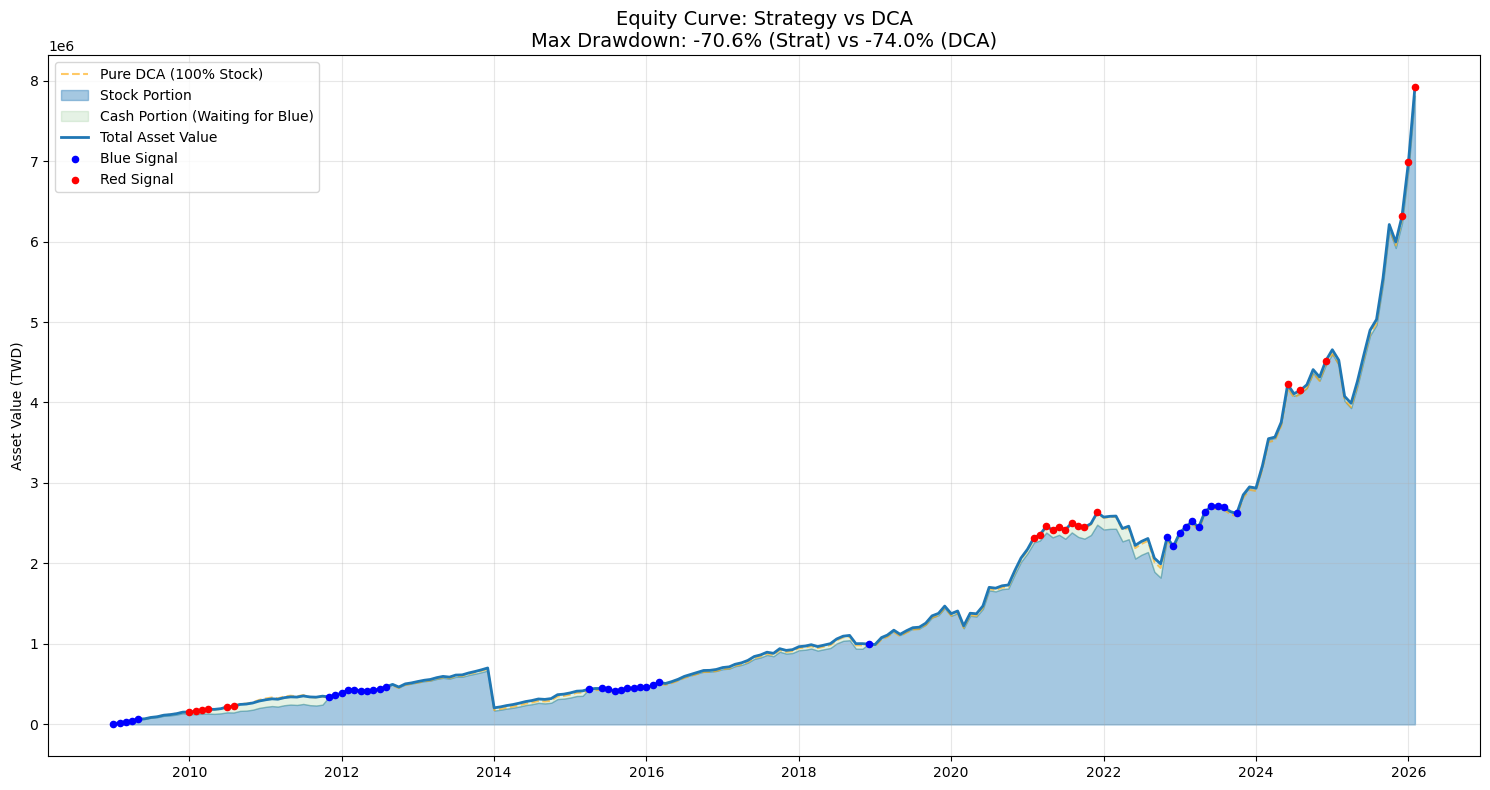

In [8]:



result_df = run_custom_strategy(final_df, my_config, monthly_budget)
final_df['DCA_Shares'] = monthly_budget / final_df['Close']
final_df['DCA_Value'] = final_df['DCA_Shares'].cumsum() * final_df['Close']


# 1. 強制對齊日期 (確保 result_df 繼承 final_df 的正確時間戳)
r = result_df.copy()
d = final_df.copy()

# 若 result_df 沒日期欄位或索引是數字，強制從 d 把正確日期抓回來
if 'Date' not in r.columns:
    # 假設兩者筆數相同且排序一致
    r['Date'] = d.index if isinstance(d.index, pd.DatetimeIndex) else pd.to_datetime(d.index)
else:
    r['Date'] = pd.to_datetime(r['Date'])

# 2. 核心指標計算 (修正 Sharpe 係數與 CAGR 基準)
def get_performance(df_strat, df_dca):
    # 總投入與期間
    total_invested = df_strat['Invest'].sum()
    days = (df_strat['Date'].iloc[-1] - df_strat['Date'].iloc[0]).days
    actual_years = max(days / 365.25, 0.1) # 防止除以 0

    # 最終價值
    v_s = df_strat['Total_Value'].iloc[-1]
    v_d = df_dca['DCA_Value'].iloc[-1]

    # CAGR (以總投入本金為分母，避免 1970 錯誤導致的倍率爆炸)
    cagr_s = (v_s / total_invested) ** (1/actual_years) - 1
    cagr_d = (v_d / total_invested) ** (1/actual_years) - 1

    # Sharpe (月資料 freq=12)
    def calc_sharpe(price_series):
        rets = price_series.pct_change().dropna()
        return np.sqrt(12) * (rets.mean() / rets.std()) if rets.std() != 0 else 0

    return {
        'total_invested': total_invested,
        'years': actual_years,
        'v_s': v_s, 'v_d': v_d,
        'cagr_s': cagr_s, 'cagr_d': cagr_d,
        'mdd_s': (df_strat['Total_Value'] / df_strat['Total_Value'].cummax() - 1).min(),
        'mdd_d': (df_dca['DCA_Value'] / df_dca['DCA_Value'].cummax() - 1).min(),
        'sharpe_s': calc_sharpe(df_strat['Total_Value']),
        'sharpe_d': calc_sharpe(df_dca['DCA_Value']),
        'start_date': df_strat['Date'].iloc[0].date(),
        'end_date': df_strat['Date'].iloc[-1].date()
    }

p = get_performance(r, d)

# 3. 輸出乾淨報表
print("\n" + "="*60)
print(f"📊 投資策略回測報告 ({p['start_date']} ~ {p['end_date']})")
print("="*60)
print(f"{'項目':<15} | {'戰術策略':>15} | {'純定期定額 (DCA)':>15}")
print("-"*60)
print(f"{'最終淨值':<15} | ${p['v_s']:14,.0f} | ${p['v_d']:14,.0f}")
print(f"{'總投入本金':<15} | ${p['total_invested']:14,.0f} | ${p['total_invested']:14,.0f}")
print(f"{'年化報酬 (CAGR)':<15} | {p['cagr_s']:14.2%} | {p['cagr_d']:14.2%}")
print(f"{'最大回撤 (MDD)':<15} | {p['mdd_s']:14.2%} | {p['mdd_d']:14.2%}")
# print(f"{'夏普值 (Sharpe)':<15} | {p['sharpe_s']:14.3f} | {p['sharpe_d']:14.3f}")
print("="*60)

# 4. 視覺化：堆疊組成圖
plt.figure(figsize=(15, 8))

# 畫出基準線
plt.plot(d.index, d['DCA_Value'], label='Pure DCA (100% Stock)', color='orange', linestyle='--', alpha=0.6)

# 畫出策略組成 (用堆疊圖看 90% 現金)
plt.fill_between(r['Date'], 0, r['Shares_Value'], label='Stock Portion', color='#1f77b4', alpha=0.4)
plt.fill_between(r['Date'], r['Shares_Value'], r['Total_Value'], label='Cash Portion (Waiting for Blue)', color='green', alpha=0.1)
plt.plot(r['Date'], r['Total_Value'], label='Total Asset Value', color='#1f77b4', linewidth=2)

# 標註藍燈區域
if 'Light' in r.columns:
    blue_days = r[r['Light'] == '藍']['Date']
    plt.scatter(blue_days, r.loc[r['Light'] == '藍', 'Total_Value'], color='blue', s=20, label='Blue Signal', zorder=5)

if 'Light' in r.columns:
    red_days = r[r['Light'] == '紅']['Date']
    plt.scatter(red_days, r.loc[r['Light'] == '紅', 'Total_Value'], color='red', s=20, label='Red Signal', zorder=5)

plt.title(f"Equity Curve: Strategy vs DCA\nMax Drawdown: {p['mdd_s']:.1%} (Strat) vs {p['mdd_d']:.1%} (DCA)", fontsize=14)
plt.ylabel("Asset Value (TWD)")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

def debug_read(file_path='ndc.xls'):
    df = pd.read_excel(file_path, engine='xlrd', header=None)

    print("📊 原始資料預覽：")
    print(df.head(15))   # 看前 15 列
    
    return df
debug_read()

📊 原始資料預覽：
          0           1          2
0       NaN  景氣對策信號(燈號)  景氣對策信號(分)
1       NaN        原始數值       原始數值
2   2003-01         NaN         20
3   2003-02         NaN         22
4   2003-03         NaN         17
5   2003-04         NaN         14
6   2003-05         NaN         14
7   2003-06         NaN         20
8   2003-07         NaN         24
9   2003-08         NaN         26
10  2003-09         NaN         29
11  2003-10         NaN         31
12  2003-11         NaN         30
13  2003-12         NaN         34
14  2004-01         NaN         35


,0,1,2
0,NaN,景氣對策信號(燈號),景氣對策信號(分)
1,NaN,原始數值,原始數值
2,2003-01,NaN,20
3,2003-02,NaN,22
4,2003-03,NaN,17
...,...,...,...
275,2025-10,NaN,35
276,2025-11,NaN,37
277,2025-12,NaN,38
278,2026-01,NaN,39
